# One declaration, two estimators

This notebook is the example on the handbook's **Experiments > Ex: random traffic** page.

An experiment is a **declaration**, and not a script. You say which parameters are held and which
vary, you give it a stack of methods and a backend, and you get one row for each condition.

The question here is a small one: **what does a resolver do to random traffic, and is the choice
of the resolver important?** Three resolvers (none, MVP, VO) against three fleet sizes (4, 6, 8
aircraft) gives nine conditions.

One declaration covers the nine, but two estimators run them. Traffic with no resolver loses
separation in a large fraction of the runs, and plain Monte Carlo measures that correctly. Traffic
with a resolver loses separation too seldom for Monte Carlo at a usual cost, thus those conditions
use the rare-event estimator. The backend is the only argument that is different between the two
calls below.

Each probability here is **for each aircraft** (`p_ac`), which is the normalisation of Blom and
Bakker. That is what makes a fleet of 4 and a fleet of 8 comparable on one axis.

In [1]:
%matplotlib inline
import math
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 130

from opencdarr import (
    M600,
    MVP,
    VO,
    Fixed,
    GnssNavigation,
    Methods,
    ProbabilisticFTR,
    RandomTraffic,
    StateBased,
    Sweep,
    geo,
    run_experiment,
)
from opencdarr.estimator import agents_for
from opencdarr.fleet import MeasurementArea, run_fleet
from opencdarr.config import (
    Config,
    ConflictConfig,
    MethodsConfig,
    ScenarioConfig,
    SimulationConfig,
)
from opencdarr.experiment import IPS, MC, Ladder

# The base config gives each parameter that no axis declares: the parameters of the encounter
# distribution, the protected zone and the horizon, and the numerics. A parameter that the
# declaration gives as Fixed or Sweep replaces the value here.
CFG = Config(
    seed=0,
    n_encounters=0,          # the backend sets this
    scenario=ScenarioConfig(aircraft_type="M600", speed=10.0, dcpa_max=50.0, tlos=60.0,
                            pos_ci95=10.0, vel_ci95=1.0),     # a 10 m / 1 m/s GNSS fix
    conflict=ConflictConfig(rpz=50.0, t_lookahead=30.0),
    methods=MethodsConfig(detection="statebased", resolution="mvp", recovery="pastcpa",
                          margin=1.05, bouncing_guard=True),  # only run_one_experiment reads this
    simulation=SimulationConfig(dt=0.5, t_max=600.0, done_timeout=10.0),
)

# The stack that stays the same in each condition. The resolver is not here, because the
# declarations below give it as an axis or as a Fixed.
STACK = Methods(detector=StateBased(), recovery=ProbabilisticFTR(),
                navigation=GnssNavigation(), perf=M600)

# One axis, used by the two calls: the fleet size builds the scenario for that condition.
FLEET = Sweep([4, 6, 8], name="n_aircraft",
              build=lambda n: RandomTraffic(n, r_inner=1000.0, r_outer=1200.0))

## First, what the three resolvers do

Before the probabilities, the tracks. One drawn fleet of 6 aircraft flies 50 times under each
resolver. The geometry is the same in the 150 runs, thus the only difference between the
repetitions of one panel is the navigation noise.

0.9 min


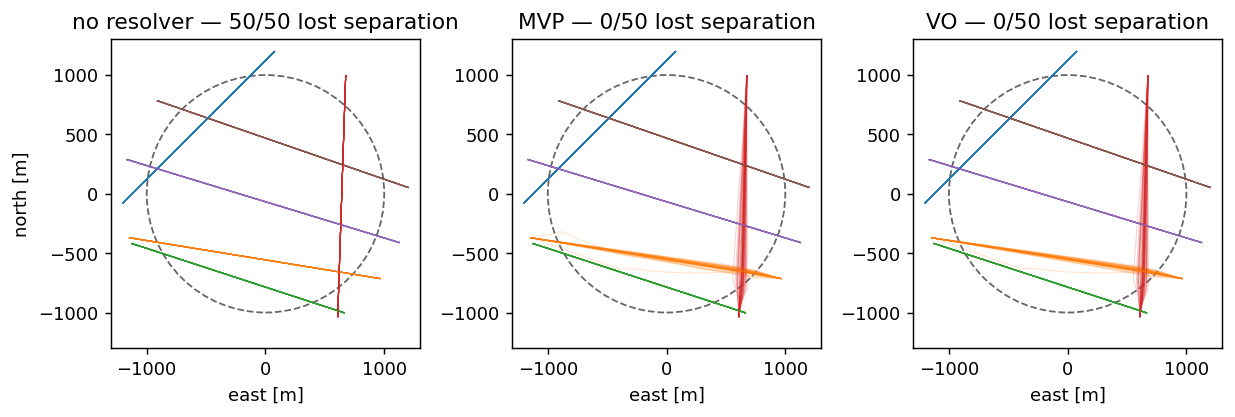

In [2]:
CENTRE, R_INNER, REPS = (52.0, 4.0), 1000.0, 50

example = RandomTraffic(6, r_inner=R_INNER, r_outer=1200.0)
drawn = example.draw(np.random.default_rng(7), CFG)                 # one arrangement
# stop_when_departed truncates the log, thus it is off while a trajectory is recorded.
area = MeasurementArea(CENTRE, R_INNER, stop_when_departed=False)


def enu(lat, lon):
    """(lat, lon) as (east, north) metres from the centre of the disc."""
    qdr, dist = geo.qdrdist(CENTRE[0], CENTRE[1], lat, lon)
    return dist * math.sin(math.radians(qdr)), dist * math.cos(math.radians(qdr))


def fly(resolver, rep):
    """One repetition: the same fleet, a new draw of the navigation noise."""
    out = run_fleet(
        agents_for(drawn, M600), rpz=50.0, t_lookahead=30.0, dt=0.5,
        detector=StateBased(), resolver=resolver, recovery=ProbabilisticFTR(),
        navigation=GnssNavigation(), rng=np.random.default_rng(1000 + rep),
        t_max=600.0, done_timeout=10.0, measure_within=area, record=True,
    )
    tracks = [np.array([enu(f.states[k].lat, f.states[k].lon) for f in out.frames.frames])
              for k in range(len(drawn))]
    return out.los, tracks


t0 = time.time()
CASES = [("no resolver", None), ("MVP", MVP(1.05)), ("VO", VO(1.05))]

fig, axes = plt.subplots(1, 3, figsize=(9.6, 3.6))
colours = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for ax, (name, resolver) in zip(axes, CASES):
    n_los = 0
    for rep in range(REPS):
        los, tracks = fly(resolver, rep)
        n_los += los
        for k, tr in enumerate(tracks):
            ax.plot(tr[:, 0], tr[:, 1], lw=0.6, alpha=0.2, color=colours[k % len(colours)])
    ax.add_patch(plt.Circle((0, 0), R_INNER, fill=False, lw=1.0, ls="--", color="0.4"))
    ax.set_title(f"{name} — {n_los}/{REPS} lost separation")
    ax.set_xlim(-1300, 1300)
    ax.set_ylim(-1300, 1300)
    ax.set_box_aspect(1)
    ax.set_xlabel("east [m]")
axes[0].set_ylabel("north [m]")
fig.tight_layout()

tracks_png = Path("../../../opencdarr.github.io/docs/assets/img/"
                  "experiment-random-traffic-tracks.png")
if tracks_png.parent.is_dir():
    fig.savefig(tracks_png, dpi=200, bbox_inches="tight")
print(f"{(time.time() - t0) / 60:.1f} min")

The dashed circle is the measured disc. Without a resolver the tracks are straight and the
pair that conflicts loses separation in each repetition. With a resolver the same pair turns, and
the width of each bundle is what the navigation noise does to that turn.

The panels give one arrangement only. The probabilities below are over the arrangements that the
scenario draws.

## The baseline: no resolver, on Monte Carlo

Without a resolver the aircraft fly their tracks and the losses are frequent, thus plain Monte
Carlo counts them directly. The denominator is the number of aircraft that flew, and the interval
is a bootstrap over the runs. A Wilson interval is not correct here: the aircraft in one run are
not independent of each other, because one conflict marks two aircraft at the same time.

In [3]:
t0 = time.time()

baseline = run_experiment(
    {"scenario": FLEET, "resolver": Fixed(None)},
    methods=STACK, backend=MC(n_encounters=500), base_config=CFG, seed=1, n_jobs=-1,
)

for row in baseline.records():
    print(f"N = {row['n_aircraft']}   P(LoS) = {row['p_ac']:.3f}   "
          f"95% CI [{row['p_ac_lo']:.3f}, {row['p_ac_hi']:.3f}]   "
          f"E[K] = {row['mean_los_pairs']:.2f}   "
          f"median closest approach {row['median_min_sep']:6.1f} m")
print(f"\n{(time.time() - t0) / 60:.1f} min")

## The two resolvers, on the rare-event estimator

The same fleet axis, a resolver axis with two levels, and a different backend. Nothing else moves.

`Sweep.build` maps each level onto the value that the run needs, thus the table reads the names
and the run receives the objects.

`Ladder` gives the shells from a pilot Monte-Carlo run of **that** condition. This is necessary
here, because a fleet of 8 aircraft loses separation much more frequently than a fleet of 4. One
fixed ladder cannot be correct for the two.

The budget is 1000 particles and 5 replications. A smaller budget of 500 particles collapsed one
replication of the most difficult condition (8 aircraft with MVP), and a collapse is a failed run
and not a data point.

`tail=True` adds a final leg that flies each survivor on to the termination. That leg is what gives
the per-aircraft number: `p_ac` is the reach probability multiplied by the mean number of aircraft
in a loss, divided by the fleet size. It does not change the reach probability.

In [ ]:
RESOLVERS = {"MVP": MVP(1.05), "VO": VO(1.05)}

t0 = time.time()

resolved = run_experiment(
    {"scenario": FLEET,
     "resolver": Sweep(["MVP", "VO"], name="resolver", build=RESOLVERS.__getitem__)},
    methods=STACK,
    backend=IPS(shells=Ladder(pilot=2000), n_particles=1000, reps=5, tail=True),
    base_config=CFG, seed=1, n_jobs=-1, cache=True,
)

for row in resolved.records():
    print(f"N = {row['n_aircraft']}  {row['resolver']:>3}   P(LoS) = {row['p_ac']:.2e}   "
          f"95% CI [{row['p_ac_lo']:.2e}, {row['p_ac_hi']:.2e}]   "
          f"collapsed {row['n_collapsed']}/{row['reps']}")
print(f"\n{(time.time() - t0) / 60:.1f} min")

In [ ]:
# The ladder that each condition used, and the survival fractions it gave.
for condition, est in zip(resolved.conditions, resolved.results):
    good = [r for r in est.reps if r.collapsed_at is None]
    surv = np.array([r.survival for r in good])
    label = ", ".join(f"{k} = {v}" for k, v in condition.label.items())
    print(f"{label:<28} {len(good[0].levels):>3} shells from "
          f"{good[0].levels[0]:>6.1f} m   survival {surv.min():.2f} to {surv.max():.2f}")

## The two tables together

The two estimators report the same quantity, `p_ac`, and they get their intervals in different
ways: a bootstrap over the runs for Monte Carlo, and a spread over the replications for IPS. The
[validation](https://fazlurnu.github.io/opencdarr.github.io/estimators/rare-event/validation/)
page is the evidence for that.

In [ ]:
rows = []
for row in baseline.records():
    rows.append({"n_aircraft": row["n_aircraft"], "resolver": "none", "backend": "MC",
                 "p_los": row["p_ac"], "lo": row["p_ac_lo"], "hi": row["p_ac_hi"]})
for row in resolved.records():
    rows.append({"n_aircraft": row["n_aircraft"], "resolver": row["resolver"], "backend": "IPS",
                 "p_los": row["p_ac"], "lo": row["p_ac_lo"], "hi": row["p_ac_hi"]})

for r in sorted(rows, key=lambda r: (r["n_aircraft"], r["resolver"])):
    print(f"N = {r['n_aircraft']}  {r['resolver']:>4}  {r['backend']:>3}   "
          f"P(LoS) = {r['p_los']:.2e}   [{r['lo']:.2e}, {r['hi']:.2e}]")

In [ ]:
fig, ax = plt.subplots(figsize=(4.2, 4.2))
sizes = [4, 6, 8]

for name in ("none", "MVP", "VO"):
    cells = [r for r in rows if r["resolver"] == name]
    cells.sort(key=lambda r: r["n_aircraft"])
    p = np.array([r["p_los"] for r in cells])
    lo = np.array([r["lo"] for r in cells])
    hi = np.array([r["hi"] for r in cells])
    line, = ax.plot(sizes, p, marker="o", label=name)
    ax.fill_between(sizes, lo, hi, alpha=0.2, color=line.get_color())

ax.set_yscale("log")
ax.set_xticks(sizes)
ax.set_xlabel("aircraft in the disc")
ax.set_ylabel("P(LoS) per aircraft")
ax.set_box_aspect(1)
ax.legend()
fig.tight_layout()

# The handbook keeps its figures in the site repository, beside this one.
out = Path("../../../opencdarr.github.io/docs/assets/img/experiment-random-traffic.png")
if out.parent.is_dir():
    fig.savefig(out, dpi=200, bbox_inches="tight")
    print(f"wrote {out}")

## What the same declaration gives you next

Nothing above knows which resolver it received. Thus an algorithm that you wrote this morning is
swept in the same way as `MVP` and `VO` here, against the same encounters and from the same seeds.

To change the estimator, change one argument. To change the traffic, change the scenario axis. The
rest of the declaration does not move.